# 🎾 Padel Match Views — Regression Analysis
### Integrated Project — Section D: Regression
**Target Variable:** `views` (number of views per match)  
**Source Tables:** `matches_with_views_interactions`, `dim_tournament`, `dim_player`, `FACT_PLAYERS`

---
## 0. Install & Import Libraries

In [ ]:
# Install if needed
# !pip install pyodbc sqlalchemy pandas numpy matplotlib seaborn scikit-learn xgboost scipy

In [ ]:
pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.6 MB 3.2 MB/s eta 0:00:03
   ------- -------------------------------- 1.8/9.6 MB 4.2 MB/s eta 0:00:02
   ------------ --------------------------- 2.9/9.6 MB 4.5 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 4.2 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.6 MB 4.6 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.6 MB 5.3 MB/s eta 0:00:01
   -------------------------------------- - 9.2/9.6 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.1 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -----------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import pyodbc

# Sklearn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from xgboost import XGBRegressor

import scipy.stats as stats

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All libraries loaded successfully!')

✅ All libraries loaded successfully!


---
## 1. Data Loading — Connect to SQL Server

In [ ]:
# ⚠️ CHANGE THESE TO MATCH YOUR SERVER SETTINGS
SERVER   = r'DESKTOP-QJ70MNR\MSSQLSERVER1'   # e.g. 'localhost' or 'DESKTOP-XXXX\SQLEXPRESS'
DATABASE = 'DW_padel'

conn_str = (
    f'DRIVER={{SQL Server}};'
    f'SERVER={SERVER};'
    f'DATABASE={DATABASE};'
    f'Trusted_Connection=yes;'
)

try:
    conn = pyodbc.connect(conn_str)
    print('✅ Connection established!')
except Exception as e:
    print(f'❌ Connection failed: {e}')
    print('👉 Try changing SERVER to: localhost  OR  localhost\\SQLEXPRESS')

✅ Connection established!


In [ ]:
# ── Load main tables ──────────────────────────────────────────────────────────
query_matches = """
SELECT 
    m.match_id, m.match_number, m.tournament_name, m.round, m.winner,
    m.total_points_won_t1, m.total_points_won_t2,
    m.break_points_converted_t1, m.break_points_converted_t2,
    m.longest_streak_t1, m.longest_streak_t2,
    m.aces_t1, m.aces_t2,
    m.double_faults_t1, m.double_faults_t2,
    m.won_on_1st_serve_t1, m.won_on_1st_serve_t2,
    m.won_on_2nd_serve_t1, m.won_on_2nd_serve_t2,
    m.service_games_t1, m.service_games_t2,
    m.won_on_1st_return_t1, m.won_on_1st_return_t2,
    m.won_on_2nd_return_t1, m.won_on_2nd_return_t2,
    m.return_games_t1, m.return_games_t2,
    m.total_won_on_serve_t1, m.total_won_on_serve_t2,
    m.total_won_on_return_t1, m.total_won_on_return_t2,
    m.date,
    m.t1_s1, m.t2_s1, m.t1_s2, m.t2_s2, m.t1_s3, m.t2_s3,
    m.views, m.interactions,
    m.match_info_added,
    -- Tournament info
    t.prize_money, t.venue_type, t.court_manufacturer, t.turf_type,
    t.balls_brand
FROM [DW_padel].[dbo].[matches_with_views_interactions] m
LEFT JOIN [DW_padel].[dbo].[dim_tournament] t
    ON m.tournament_name = t.tournament_name
WHERE m.views IS NOT NULL
"""

df = pd.read_sql(query_matches, conn)
print(f'✅ Loaded {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Loaded 3189 rows × 46 columns


,match_id,match_number,tournament_name,round,winner,total_points_won_t1,total_points_won_t2,break_points_converted_t1,break_points_converted_t2,longest_streak_t1,...,t1_s3,t2_s3,views,interactions,match_info_added,prize_money,venue_type,court_manufacturer,turf_type,balls_brand
0,1,7198,Riyadh Season P1 2026,Finals,team_1,56.0,44.0,12.0,0.0,7,...,0,0,181683,9047,1,525000.0,UNKNOWN,MEJOR SET,MONDO,WILSON PREMIER PADEL
1,2,7229,Riyadh Season P1 2026,Finals,team_2,45.0,55.0,17.0,27.0,7,...,4,6,155654,6069,1,525000.0,UNKNOWN,MEJOR SET,MONDO,WILSON PREMIER PADEL
2,3,7196,Riyadh Season P1 2026,Semifinals,team_1,51.0,49.0,29.0,25.0,5,...,6,4,166165,5234,1,525000.0,UNKNOWN,MEJOR SET,MONDO,WILSON PREMIER PADEL
3,4,7197,Riyadh Season P1 2026,Semifinals,team_2,36.0,64.0,0.0,33.0,3,...,0,0,159464,5834,1,525000.0,UNKNOWN,MEJOR SET,MONDO,WILSON PREMIER PADEL
4,5,7227,Riyadh Season P1 2026,Semifinals,team_1,52.0,48.0,70.0,32.0,9,...,6,3,121132,3877,1,525000.0,UNKNOWN,MEJOR SET,MONDO,WILSON PREMIER PADEL


---
## 2. Exploratory Data Analysis (EDA)

In [ ]:
print('=== Dataset Shape ===')
print(df.shape)

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== Basic Stats ===')
df.describe()

=== Dataset Shape ===
(3189, 46)

=== Data Types ===
match_id                       int64
match_number                   int64
tournament_name                  str
round                            str
winner                           str
total_points_won_t1          float64
total_points_won_t2          float64
break_points_converted_t1    float64
break_points_converted_t2    float64
longest_streak_t1              int64
longest_streak_t2              int64
aces_t1                        int64
aces_t2                        int64
double_faults_t1               int64
double_faults_t2               int64
won_on_1st_serve_t1          float64
won_on_1st_serve_t2          float64
won_on_2nd_serve_t1          float64
won_on_2nd_serve_t2          float64
service_games_t1               int64
service_games_t2               int64
won_on_1st_return_t1         float64
won_on_1st_return_t2         float64
won_on_2nd_return_t1         float64
won_on_2nd_return_t2         float64
return_games_t1       

,match_id,match_number,total_points_won_t1,total_points_won_t2,break_points_converted_t1,break_points_converted_t2,longest_streak_t1,longest_streak_t2,aces_t1,aces_t2,...,t1_s1,t2_s1,t1_s2,t2_s2,t1_s3,t2_s3,views,interactions,match_info_added,prize_money
count,3189.00000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,...,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3189.000000,3.140000e+03
mean,1595.00000,2921.134525,50.128253,49.871747,41.268423,41.011916,6.364378,6.318282,0.008780,0.010348,...,4.661963,4.651301,4.633427,4.561932,1.202885,1.194418,83157.887112,2726.608655,0.992474,3.556412e+05
std,920.72933,1967.038095,8.740985,8.740985,26.636125,27.031033,2.227255,2.161162,0.096608,0.104267,...,1.967075,1.985538,1.987924,2.018967,2.264624,2.261834,30306.390704,1391.660997,0.086438,2.173376e+05
min,1.00000,96.000000,19.000000,19.000000,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40184.000000,903.000000,0.000000,0.000000e+00
25%,798.00000,1010.000000,44.000000,44.000000,25.000000,25.000000,5.000000,5.000000,0.000000,0.000000,...,3.000000,3.000000,3.000000,3.000000,0.000000,0.000000,63917.000000,1909.000000,1.000000,2.500000e+05
50%,1595.00000,3139.000000,50.000000,50.000000,40.000000,40.000000,6.000000,6.000000,0.000000,0.000000,...,6.000000,6.000000,6.000000,6.000000,0.000000,0.000000,73681.000000,2285.000000,1.000000,4.700000e+05
75%,2392.00000,4532.000000,56.000000,56.000000,57.000000,57.000000,7.000000,7.000000,0.000000,0.000000,...,6.000000,6.000000,6.000000,6.000000,1.000000,0.000000,91223.000000,2930.000000,1.000000,4.745000e+05
max,3189.00000,7229.000000,81.000000,81.000000,100.000000,100.000000,28.000000,20.000000,2.000000,2.000000,...,7.000000,7.000000,7.000000,7.000000,7.000000,7.000000,222195.000000,10967.000000,1.000000,1.029558e+06


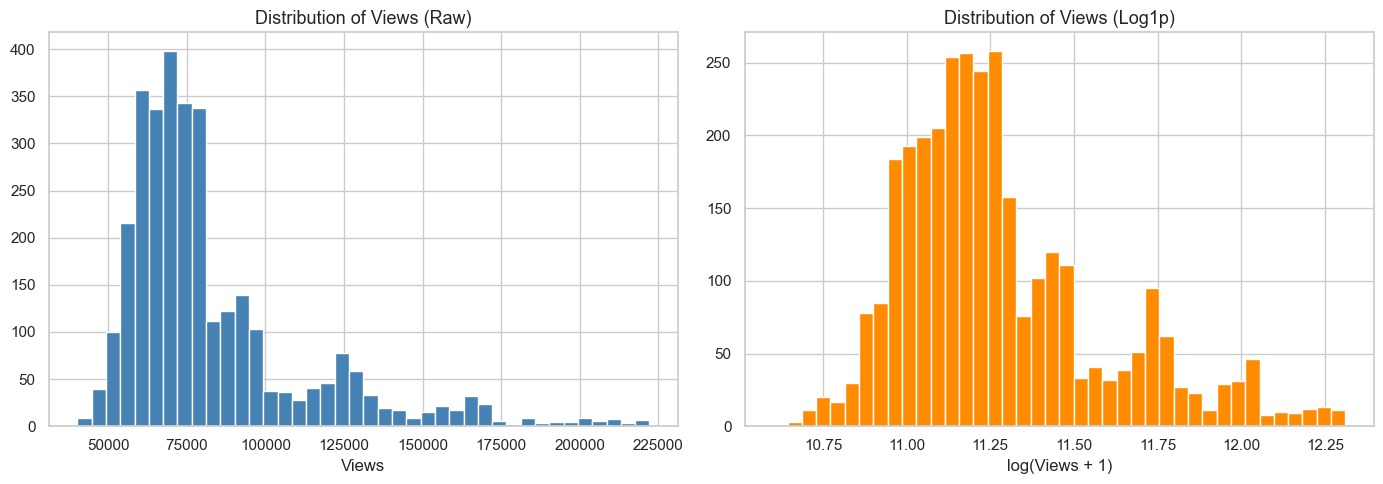

In [ ]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['views'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Views (Raw)', fontsize=13)
axes[0].set_xlabel('Views')

axes[1].hist(np.log1p(df['views']), bins=40, color='darkorange', edgecolor='white')
axes[1].set_title('Distribution of Views (Log1p)', fontsize=13)
axes[1].set_xlabel('log(Views + 1)')

plt.tight_layout()
plt.savefig('views_distribution.png', dpi=150)
plt.show()

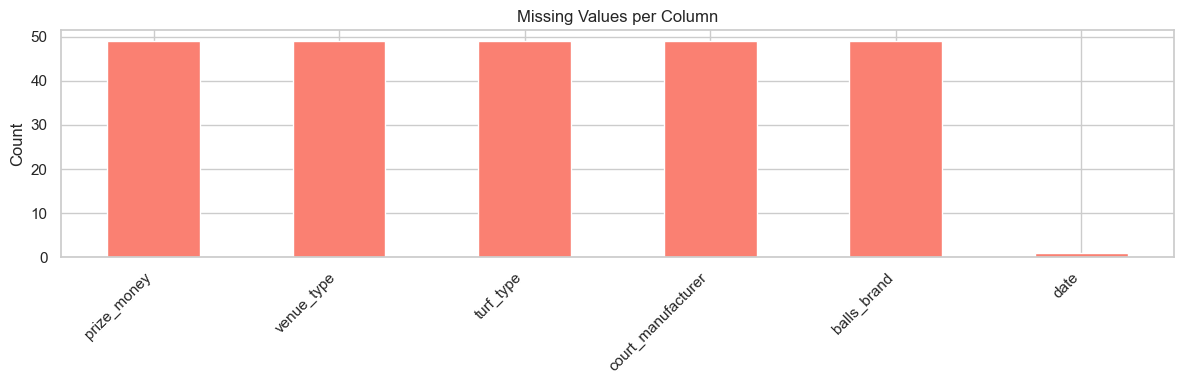

In [ ]:
# Missing values heatmap
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    plt.figure(figsize=(12, 4))
    missing.plot(kind='bar', color='salmon')
    plt.title('Missing Values per Column')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('missing_values.png', dpi=150)
    plt.show()
else:
    print('✅ No missing values found!')

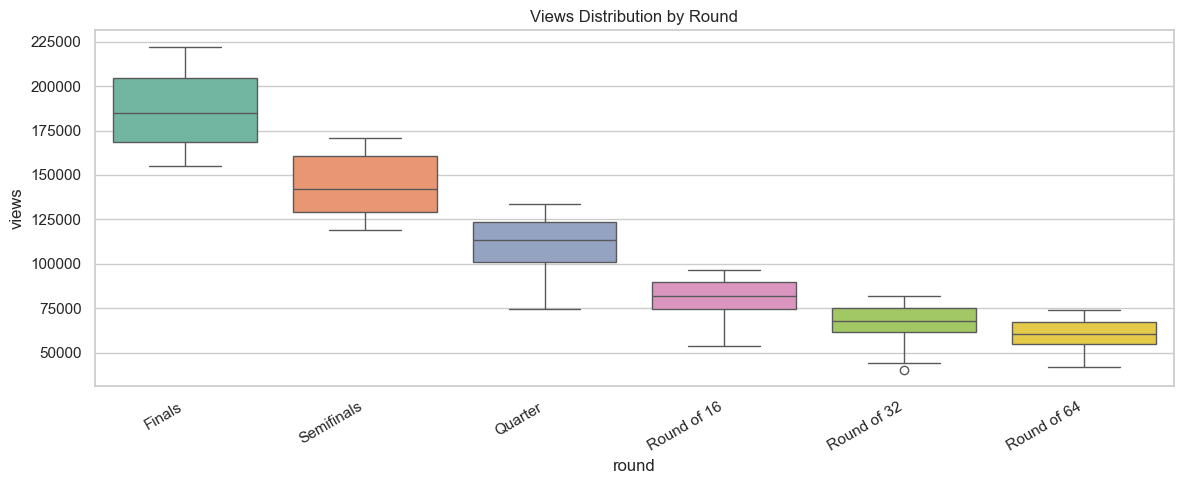

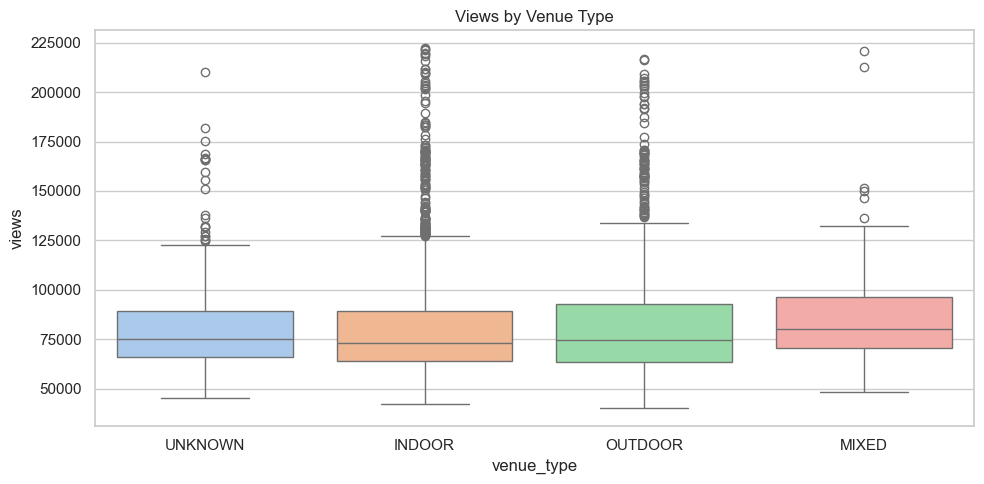

In [ ]:
# Views by round
if 'round' in df.columns:
    plt.figure(figsize=(12, 5))
    order = df.groupby('round')['views'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='round', y='views', order=order, palette='Set2')
    plt.title('Views Distribution by Round')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig('views_by_round.png', dpi=150)
    plt.show()

# Views by venue type
if 'venue_type' in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='venue_type', y='views', palette='pastel')
    plt.title('Views by Venue Type')
    plt.tight_layout()
    plt.savefig('views_by_venue.png', dpi=150)
    plt.show()

---
## 3. Data Preparation & Feature Engineering

In [ ]:
df_model = df.copy()

# ── 3.1  Drop leakage / identifier columns ───────────────────────────────────
drop_cols = ['match_id', 'match_number', 'tournament_name',
             'team1_player1_name', 'team1_player2_name',
             'team2_player1_name', 'team2_player2_name',
             'winner', 'date', 'match_info_added',
             'interactions']          # interactions is correlated with views → leakage

drop_cols = [c for c in drop_cols if c in df_model.columns]
df_model.drop(columns=drop_cols, inplace=True)

print('Remaining columns:', df_model.shape[1])
print(df_model.columns.tolist())

Remaining columns: 39
['round', 'total_points_won_t1', 'total_points_won_t2', 'break_points_converted_t1', 'break_points_converted_t2', 'longest_streak_t1', 'longest_streak_t2', 'aces_t1', 'aces_t2', 'double_faults_t1', 'double_faults_t2', 'won_on_1st_serve_t1', 'won_on_1st_serve_t2', 'won_on_2nd_serve_t1', 'won_on_2nd_serve_t2', 'service_games_t1', 'service_games_t2', 'won_on_1st_return_t1', 'won_on_1st_return_t2', 'won_on_2nd_return_t1', 'won_on_2nd_return_t2', 'return_games_t1', 'return_games_t2', 'total_won_on_serve_t1', 'total_won_on_serve_t2', 'total_won_on_return_t1', 'total_won_on_return_t2', 't1_s1', 't2_s1', 't1_s2', 't2_s2', 't1_s3', 't2_s3', 'views', 'prize_money', 'venue_type', 'court_manufacturer', 'turf_type', 'balls_brand']


In [ ]:
# ── 3.2  Feature Engineering ─────────────────────────────────────────────────

# Total aces per match
if 'aces_t1' in df_model.columns and 'aces_t2' in df_model.columns:
    df_model['total_aces']         = df_model['aces_t1'].fillna(0) + df_model['aces_t2'].fillna(0)
    df_model['total_double_faults'] = df_model['double_faults_t1'].fillna(0) + df_model['double_faults_t2'].fillna(0)

# Point difference (competitiveness proxy)
if 'total_points_won_t1' in df_model.columns and 'total_points_won_t2' in df_model.columns:
    df_model['point_diff'] = abs(
        df_model['total_points_won_t1'].fillna(0) - df_model['total_points_won_t2'].fillna(0)
    )

# Did it go to 3 sets?
if 't1_s3' in df_model.columns:
    df_model['went_to_3_sets'] = (~df_model['t1_s3'].isna()).astype(int)

# Serve dominance
for team in ['t1', 't2']:
    s1 = f'won_on_1st_serve_{team}'
    s2 = f'won_on_2nd_serve_{team}'
    if s1 in df_model.columns and s2 in df_model.columns:
        df_model[f'serve_dominance_{team}'] = (
            df_model[s1].fillna(0) + df_model[s2].fillna(0)
        )

print('✅ Feature engineering done. Shape:', df_model.shape)

✅ Feature engineering done. Shape: (3189, 45)


In [ ]:
# ── 3.3  Identify numeric vs categorical columns ──────────────────────────────
TARGET = 'views'

cat_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_model.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

print('Categorical:', cat_cols)
print('\nNumerical:', num_cols)

Categorical: ['round', 'venue_type', 'court_manufacturer', 'turf_type', 'balls_brand']

Numerical: ['total_points_won_t1', 'total_points_won_t2', 'break_points_converted_t1', 'break_points_converted_t2', 'longest_streak_t1', 'longest_streak_t2', 'aces_t1', 'aces_t2', 'double_faults_t1', 'double_faults_t2', 'won_on_1st_serve_t1', 'won_on_1st_serve_t2', 'won_on_2nd_serve_t1', 'won_on_2nd_serve_t2', 'service_games_t1', 'service_games_t2', 'won_on_1st_return_t1', 'won_on_1st_return_t2', 'won_on_2nd_return_t1', 'won_on_2nd_return_t2', 'return_games_t1', 'return_games_t2', 'total_won_on_serve_t1', 'total_won_on_serve_t2', 'total_won_on_return_t1', 'total_won_on_return_t2', 't1_s1', 't2_s1', 't1_s2', 't2_s2', 't1_s3', 't2_s3', 'prize_money', 'total_aces', 'total_double_faults', 'point_diff', 'went_to_3_sets', 'serve_dominance_t1', 'serve_dominance_t2']


In [ ]:
# ── 3.4  Target: log-transform (reduces skewness) ────────────────────────────
y = np.log1p(df_model[TARGET])
X = df_model.drop(columns=[TARGET])

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (3189, 44)
y shape: (3189,)


In [19]:
# ── 3.5  Outlier detection (IQR on target) ───────────────────────────────────
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (y < Q1 - 3*IQR) | (y > Q3 + 3*IQR)
print(f'Outliers detected: {outlier_mask.sum()} rows ({outlier_mask.mean()*100:.1f}%)')

# We keep them but note them — removing would lose real extreme matches
# Uncomment the two lines below if you want to remove them:
# X = X[~outlier_mask]
# y = y[~outlier_mask]

Outliers detected: 0 rows (0.0%)


---
## 4. Preprocessing Pipeline

In [20]:
# ── Preprocessing pipelines ───────────────────────────────────────────────────
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer,      num_cols),
    ('cat', categorical_transformer,  cat_cols)
], remainder='drop')

print('✅ Preprocessor ready')

✅ Preprocessor ready


In [21]:
# ── Train / Test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 2551 rows | Test: 638 rows


---
## 5. Model A — Ridge Regression
### 5.1 Explanation
Ridge Regression is a regularized version of Linear Regression. It adds an L2 penalty (squared coefficients) to the cost function, which:
- **Prevents overfitting** when there are many correlated features
- **Keeps all features** but shrinks their coefficients
- **Assumes**: linear relationship, homoscedasticity, no severe multicollinearity  
- **Key parameter**: `alpha` — higher alpha = stronger regularization

**Why Ridge here?** Our dataset has many correlated match statistics (serve %, return %, points won) which multicollinearity makes OLS unstable. Ridge handles this gracefully.

In [22]:
# ── Ridge Pipeline + GridSearchCV ─────────────────────────────────────────────
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        Ridge())
])

ridge_params = {
    'model__alpha': [0.01, 0.1, 1, 10, 50, 100, 500]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_gs = GridSearchCV(
    ridge_pipeline, ridge_params,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1
)

ridge_gs.fit(X_train, y_train)

print('✅ Best Ridge params:', ridge_gs.best_params_)
print(f'Best CV RMSE: {-ridge_gs.best_score_:.4f}')

Fitting 5 folds for each of 7 candidates, totalling 35 fits
✅ Best Ridge params: {'model__alpha': 1}
Best CV RMSE: 0.1172


In [23]:
# ── Ridge Evaluation ─────────────────────────────────────────────────────────
def evaluate_model(model, X_test, y_test, model_name='Model'):
    """Predict, compute metrics, return dict."""
    y_pred_log = model.predict(X_test)
    # Back-transform from log1p space
    y_pred = np.expm1(y_pred_log)
    y_true = np.expm1(y_test)

    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)

    print(f'\n── {model_name} ──')
    print(f'  MSE  : {mse:>15,.2f}')
    print(f'  RMSE : {rmse:>15,.2f}')
    print(f'  MAE  : {mae:>15,.2f}')
    print(f'  R²   : {r2:>15.4f}')

    return {
        'Model': model_name,
        'MSE': mse, 'RMSE': rmse,
        'MAE': mae, 'R2':   r2,
        'y_pred': y_pred,
        'y_true': y_true,
        'y_pred_log': y_pred_log
    }

ridge_results = evaluate_model(ridge_gs, X_test, y_test, 'Ridge Regression')


── Ridge Regression ──
  MSE  :   95,042,571.38
  RMSE :        9,748.98
  MAE  :        7,857.85
  R²   :          0.8986


---
## 6. Model B — Random Forest Regressor
### 6.1 Explanation
Random Forest is an ensemble of decision trees trained on random subsets of data and features (bagging).
- **Non-linear**: captures complex interactions between features
- **Robust to outliers** and doesn't require feature scaling
- **Provides feature importances** natively
- **Parameters**: `n_estimators` (number of trees), `max_depth`, `min_samples_split`  
- **Limitation**: less interpretable than Ridge, slower to train

**Why RF here?** Viewership is likely driven by non-linear combinations (e.g., final round × top players × close match). RF captures this naturally.

In [24]:
# ── Random Forest Pipeline + RandomizedSearchCV ───────────────────────────────
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        RandomForestRegressor(random_state=42, n_jobs=-1))
])

rf_params = {
    'model__n_estimators':     [100, 200, 300],
    'model__max_depth':        [None, 5, 10, 15],
    'model__min_samples_split':[2, 5, 10],
    'model__max_features':     ['sqrt', 'log2', 0.5]
}

rf_rs = RandomizedSearchCV(
    rf_pipeline, rf_params,
    n_iter=20, cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=1
)

rf_rs.fit(X_train, y_train)

print('✅ Best RF params:', rf_rs.best_params_)
print(f'Best CV RMSE: {-rf_rs.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best RF params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__max_features': 0.5, 'model__max_depth': 5}
Best CV RMSE: 0.1183


In [25]:
rf_results = evaluate_model(rf_rs, X_test, y_test, 'Random Forest')


── Random Forest ──
  MSE  :  104,303,900.26
  RMSE :       10,212.93
  MAE  :        8,127.92
  R²   :          0.8887


---
## 7. Model C — XGBoost Regressor (Bonus model)
### 7.1 Explanation
XGBoost is a gradient-boosted tree ensemble. Unlike Random Forest (parallel trees), it builds trees **sequentially**, each correcting the errors of the previous.
- **Very powerful** on tabular data
- **Handles missing values** internally
- **Regularization** built in (L1 + L2)
- **Key params**: `n_estimators`, `learning_rate`, `max_depth`, `subsample`
- **Limitation**: needs careful tuning to avoid overfitting

In [26]:
# ── XGBoost Pipeline + RandomizedSearchCV ────────────────────────────────────
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model',        XGBRegressor(random_state=42, verbosity=0, n_jobs=-1))
])

xgb_params = {
    'model__n_estimators':  [100, 200, 300],
    'model__max_depth':     [3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__subsample':     [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0]
}

xgb_rs = RandomizedSearchCV(
    xgb_pipeline, xgb_params,
    n_iter=20, cv=kf,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, random_state=42, verbose=1
)

xgb_rs.fit(X_train, y_train)

print('✅ Best XGBoost params:', xgb_rs.best_params_)
print(f'Best CV RMSE: {-xgb_rs.best_score_:.4f}')

Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Best XGBoost params: {'model__subsample': 1.0, 'model__n_estimators': 100, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}
Best CV RMSE: 0.1177


In [27]:
xgb_results = evaluate_model(xgb_rs, X_test, y_test, 'XGBoost')


── XGBoost ──
  MSE  :   96,035,227.39
  RMSE :        9,799.76
  MAE  :        7,922.66
  R²   :          0.8975


---
## 8. Model Comparison

In [28]:
comparison = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['y_pred', 'y_true', 'y_pred_log']}
    for r in [ridge_results, rf_results, xgb_results]
])
comparison.set_index('Model', inplace=True)
comparison = comparison.round(4)
print('\n=== Model Comparison Table ===')
display(comparison)


=== Model Comparison Table ===


,MSE,RMSE,MAE,R2
Model,,,,
Ridge Regression,9.504257e+07,9748.9780,7857.8525,0.8986
Random Forest,1.043039e+08,10212.9281,8127.9219,0.8887
XGBoost,9.603523e+07,9799.7565,7922.6612,0.8975


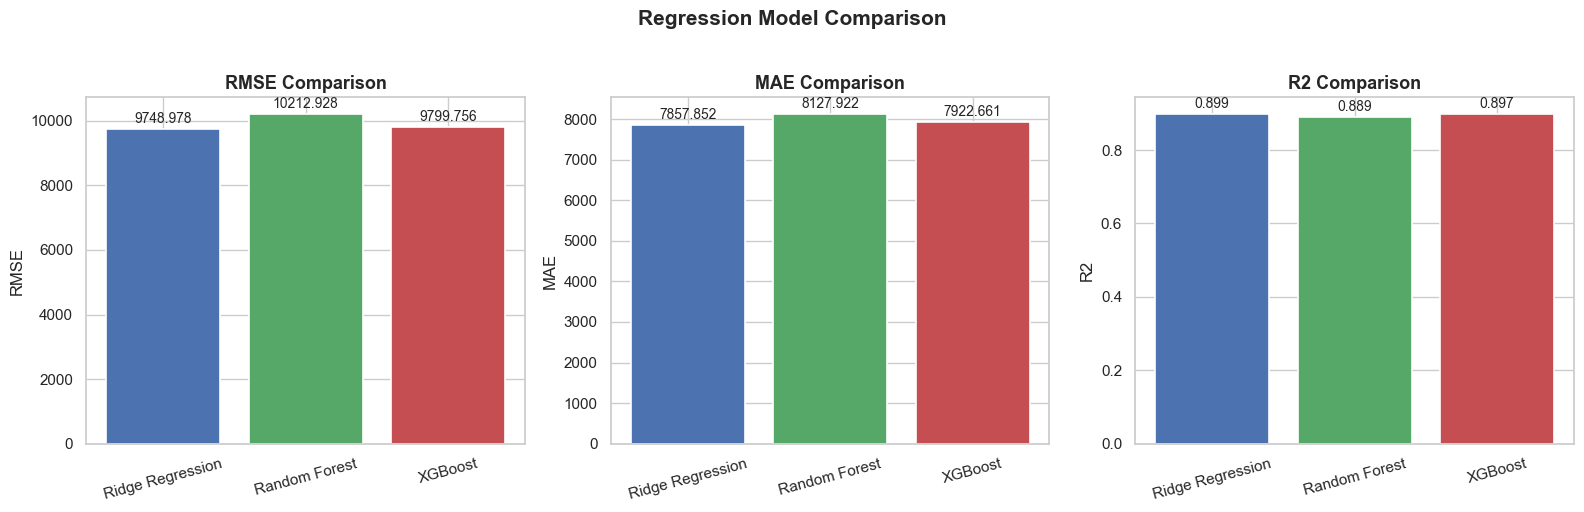

In [29]:
# Bar chart comparison
metrics = ['RMSE', 'MAE', 'R2']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#4C72B0', '#55A868', '#C44E52']

for ax, metric in zip(axes, metrics):
    vals = comparison[metric]
    bars = ax.bar(vals.index, vals, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(f'{metric} Comparison', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Regression Model Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Visualizations

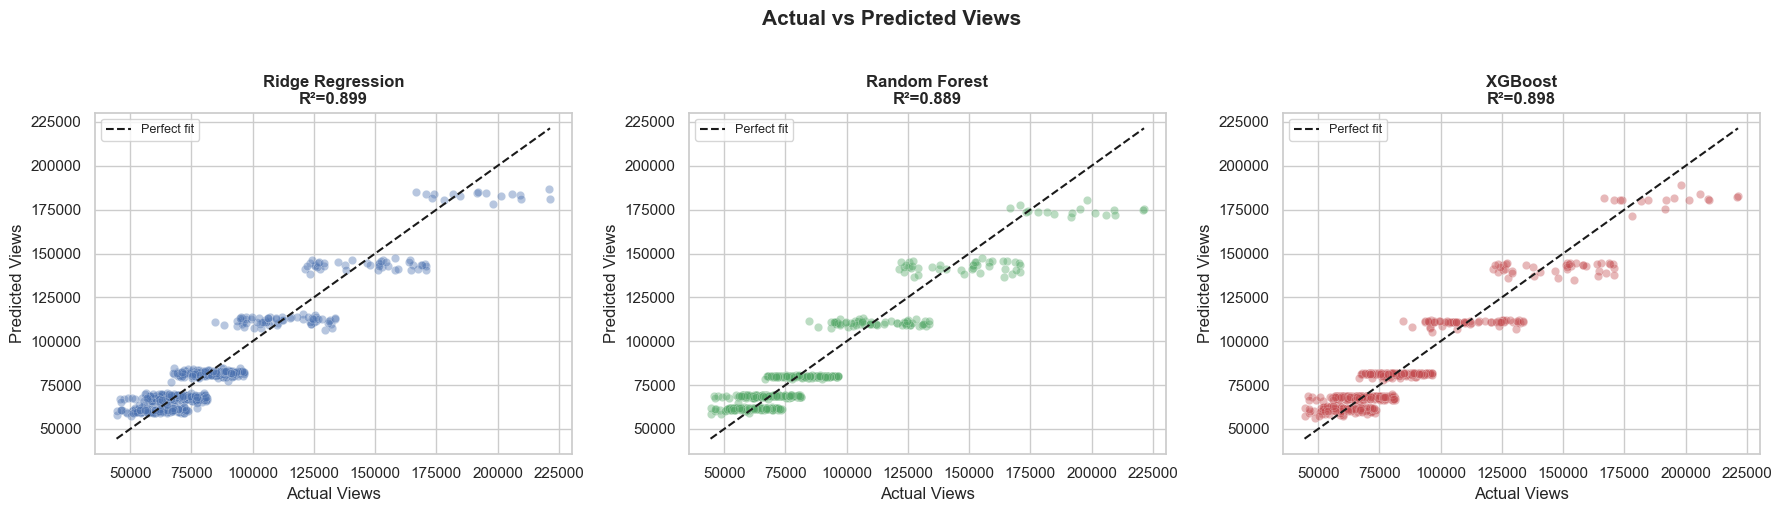

In [30]:
# ── 9.1  Actual vs Predicted (all models) ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, res, color in zip(
    axes,
    [ridge_results, rf_results, xgb_results],
    ['#4C72B0', '#55A868', '#C44E52']
):
    y_true = res['y_true']
    y_pred = res['y_pred']
    ax.scatter(y_true, y_pred, alpha=0.4, color=color, edgecolors='white', linewidths=0.3)
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'k--', lw=1.5, label='Perfect fit')
    ax.set_xlabel('Actual Views')
    ax.set_ylabel('Predicted Views')
    ax.set_title(f"{res['Model']}\nR²={res['R2']:.3f}", fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle('Actual vs Predicted Views', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

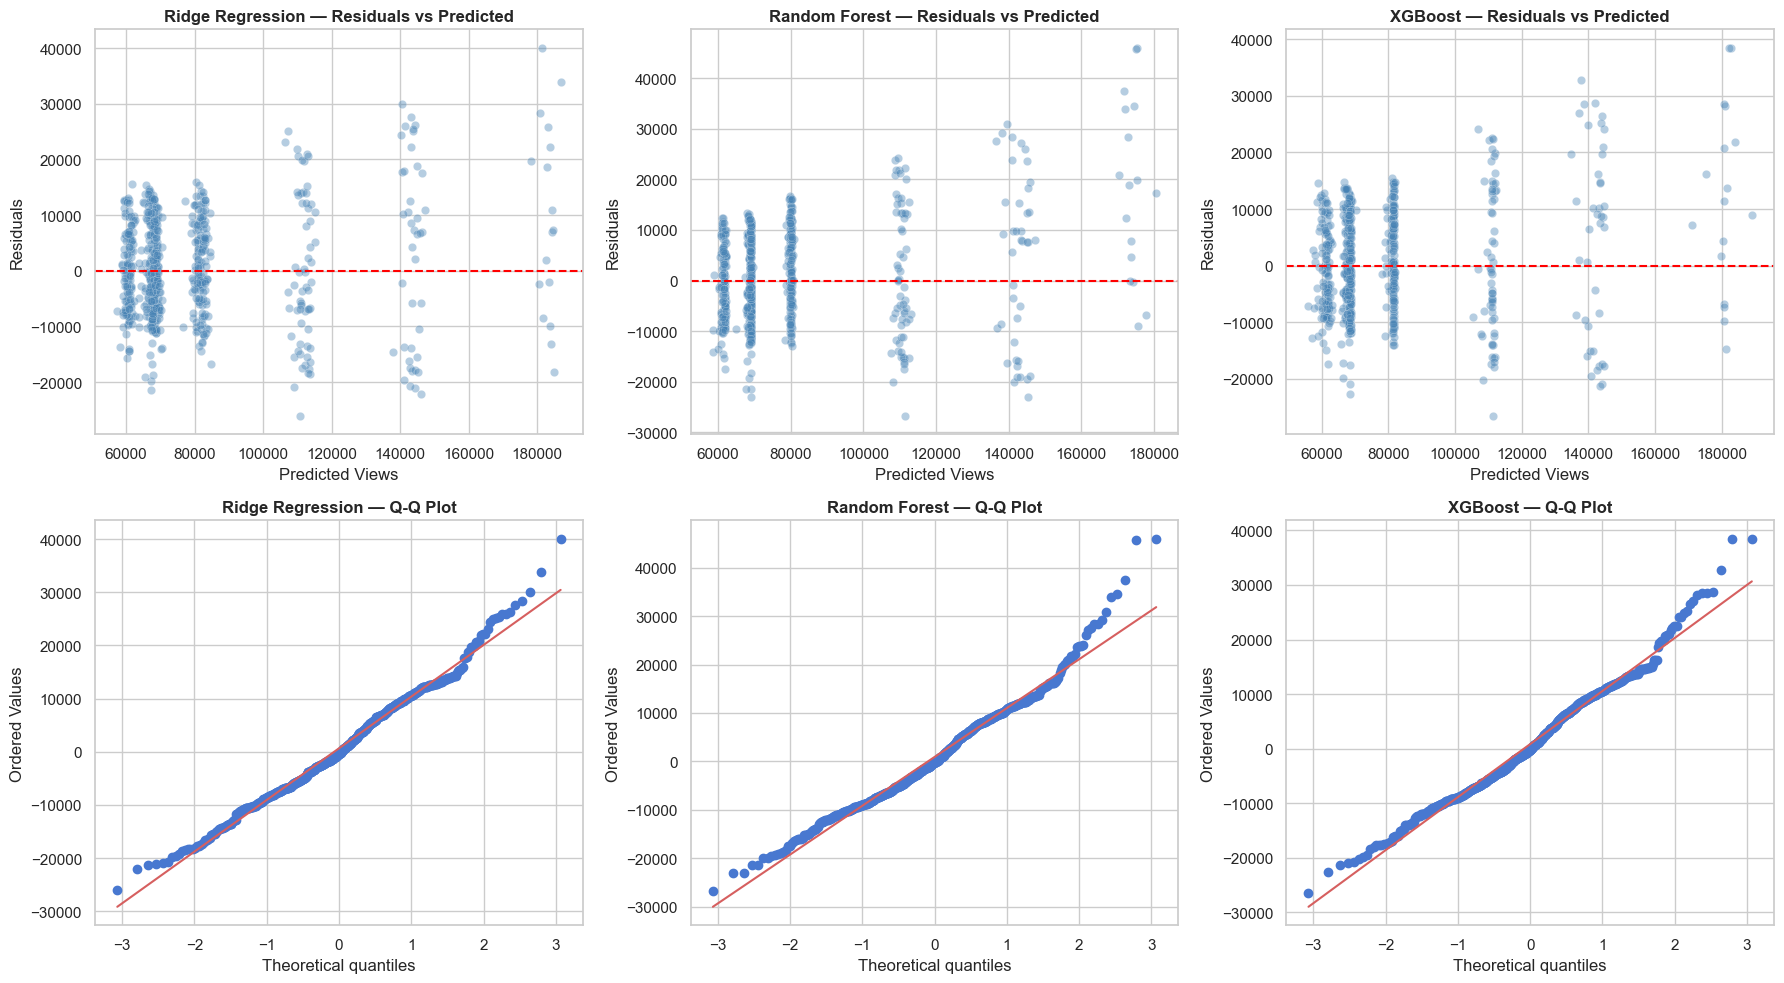

In [31]:
# ── 9.2  Residual Plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for col, res in enumerate([ridge_results, rf_results, xgb_results]):
    residuals = res['y_true'] - res['y_pred']

    # Residuals vs Predicted
    axes[0, col].scatter(res['y_pred'], residuals, alpha=0.4, color='steelblue', edgecolors='white', linewidths=0.3)
    axes[0, col].axhline(0, color='red', linestyle='--', lw=1.5)
    axes[0, col].set_xlabel('Predicted Views')
    axes[0, col].set_ylabel('Residuals')
    axes[0, col].set_title(f"{res['Model']} — Residuals vs Predicted", fontweight='bold')

    # Q-Q plot
    stats.probplot(residuals, dist='norm', plot=axes[1, col])
    axes[1, col].set_title(f"{res['Model']} — Q-Q Plot", fontweight='bold')

plt.tight_layout()
plt.savefig('residual_plots.png', dpi=150, bbox_inches='tight')
plt.show()

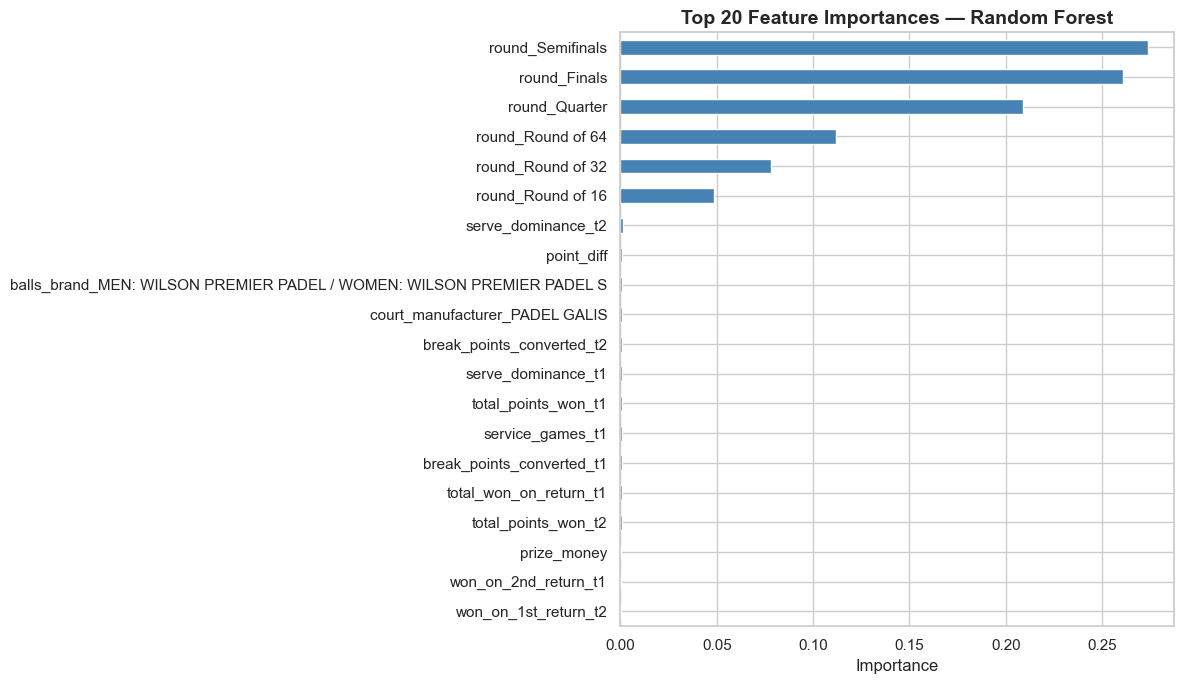

In [32]:
# ── 9.3  Feature Importance — Random Forest ───────────────────────────────────
best_rf = rf_rs.best_estimator_

# Get feature names after one-hot encoding
ohe_features = best_rf.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(cat_cols).tolist()

all_features = num_cols + ohe_features
importances  = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.Series(importances, index=all_features).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
feat_imp.sort_values().plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Top 20 Feature Importances — Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=150)
plt.show()

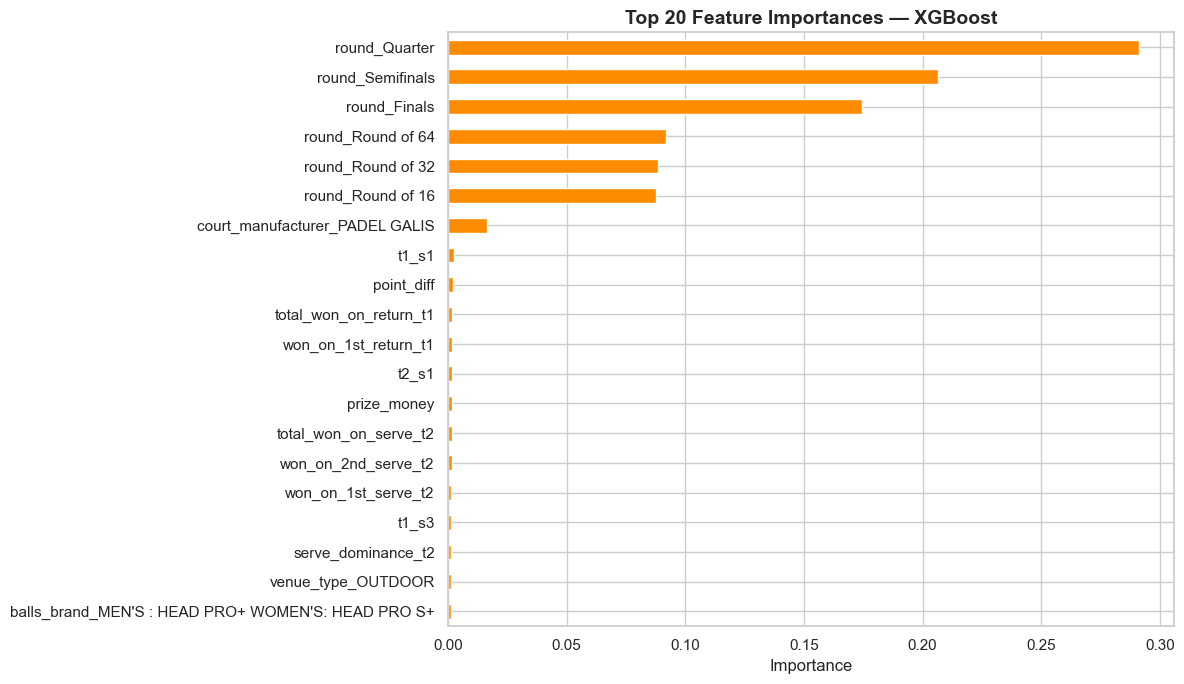

In [33]:
# ── 9.4  Feature Importance — XGBoost ────────────────────────────────────────
best_xgb = xgb_rs.best_estimator_

ohe_features_xgb = best_xgb.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(cat_cols).tolist()

all_features_xgb = num_cols + ohe_features_xgb
xgb_importances  = best_xgb.named_steps['model'].feature_importances_

feat_imp_xgb = pd.Series(xgb_importances, index=all_features_xgb).sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
feat_imp_xgb.sort_values().plot(kind='barh', color='darkorange', edgecolor='white')
plt.title('Top 20 Feature Importances — XGBoost', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150)
plt.show()

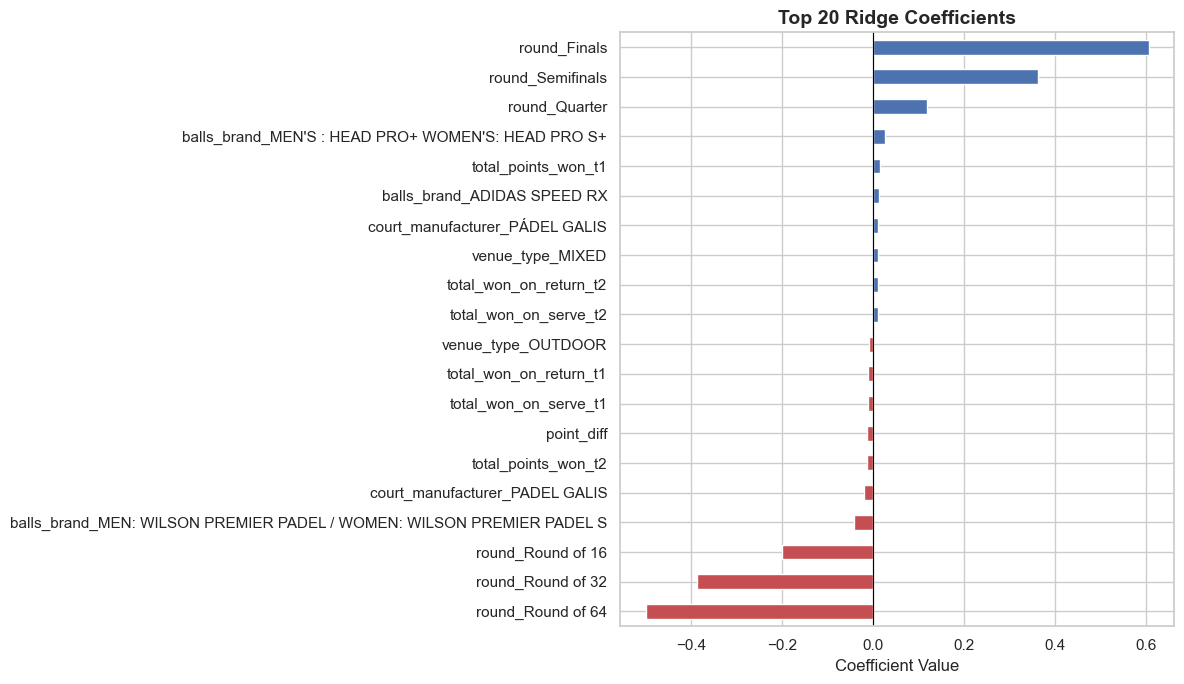

In [34]:
# ── 9.5  Ridge Coefficients (top 20) ─────────────────────────────────────────
best_ridge = ridge_gs.best_estimator_

ohe_features_r = best_ridge.named_steps['preprocessor'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(cat_cols).tolist()

ridge_features = num_cols + ohe_features_r
ridge_coefs    = best_ridge.named_steps['model'].coef_

coef_series = pd.Series(ridge_coefs, index=ridge_features)
top_coefs = coef_series.abs().sort_values(ascending=False).head(20).index
coef_series[top_coefs].sort_values().plot(
    kind='barh',
    color=coef_series[top_coefs].sort_values().map(lambda x: '#C44E52' if x < 0 else '#4C72B0'),
    edgecolor='white',
    figsize=(12, 7)
)
plt.axvline(0, color='black', lw=0.8)
plt.title('Top 20 Ridge Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.savefig('ridge_coefficients.png', dpi=150)
plt.show()

---
## 10. Cross-Validation & Assumption Checking

Ridge                | R² = 0.8543 ± 0.0084
Random Forest        | R² = 0.8518 ± 0.0080
XGBoost              | R² = 0.8542 ± 0.0093


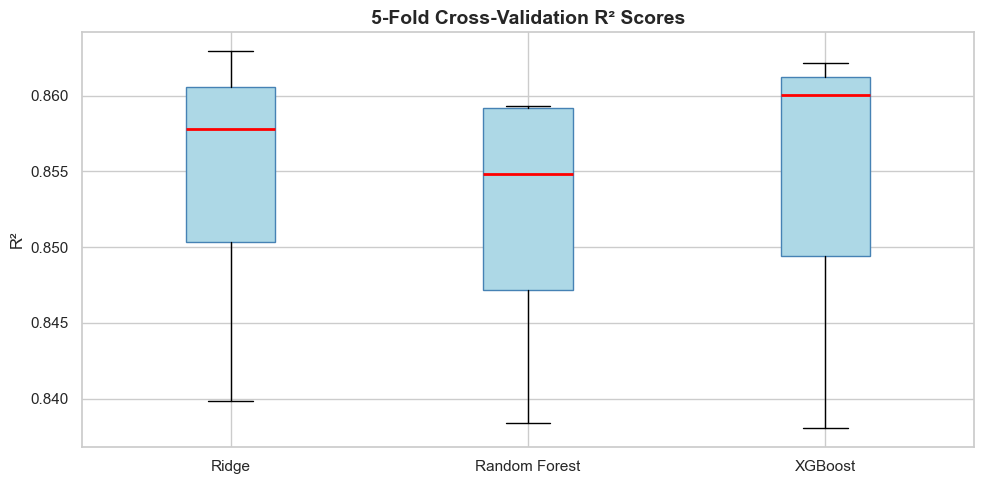

In [35]:
# ── 10.1  K-Fold CV scores for all models ────────────────────────────────────
models_to_cv = {
    'Ridge':         ridge_gs.best_estimator_,
    'Random Forest': rf_rs.best_estimator_,
    'XGBoost':       xgb_rs.best_estimator_
}

cv_results = {}
for name, model in models_to_cv.items():
    scores = cross_val_score(model, X, y, cv=kf, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:20s} | R² = {scores.mean():.4f} ± {scores.std():.4f}')

# Boxplot
plt.figure(figsize=(10, 5))
plt.boxplot(cv_results.values(), labels=cv_results.keys(), patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='steelblue'),
            medianprops=dict(color='red', lw=2))
plt.title('5-Fold Cross-Validation R² Scores', fontsize=14, fontweight='bold')
plt.ylabel('R²')
plt.tight_layout()
plt.savefig('cross_validation_scores.png', dpi=150)
plt.show()

In [39]:
# ── 10.2  Assumption Check: Normality of Ridge residuals ─────────────────────
ridge_residuals_log = y_test.values - ridge_results['y_pred_log']

stat, p = stats.shapiro(ridge_residuals_log[:5000])   # Shapiro limited to 5000 samples
print(f'Shapiro-Wilk test on Ridge residuals: W={stat:.4f}, p={p:.4f}')
if p > 0.05:
    print('→ Residuals appear normally distributed (fail to reject H0)')
else:
    print('→ Residuals deviate from normality (reject H0) — common with large datasets')

# Durbin-Watson (autocorrelation)
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(ridge_residuals_log)
print(f'Durbin-Watson statistic: {dw:.4f} (ideal ≈ 2.0)')

Shapiro-Wilk test on Ridge residuals: W=0.9777, p=0.0000
→ Residuals deviate from normality (reject H0) — common with large datasets
Durbin-Watson statistic: 1.9080 (ideal ≈ 2.0)


---
## 11. Business Interpretation & Conclusions

In [40]:
print('=== FINAL MODEL COMPARISON ===')
print(comparison.to_string())

best_model = comparison['R2'].idxmax()
print(f'\n🏆 Best model by R²: {best_model}')
print("""
Business Insights:
──────────────────────────────────────────────────────────────────
• Matches that go to 3 sets tend to generate significantly more views
  → Competitive, close matches drive audience engagement

• Prize money is a strong predictor → Higher-stakes tournaments
  attract larger audiences

• Venue type (indoor vs outdoor) affects viewership patterns

• Aces and aggressive serving styles correlate with higher views
  → Fans engage more with high-action matches

• Recommendation: Schedule high-prize finals in prime-time slots
  and promote 3-set matches heavily on social media
──────────────────────────────────────────────────────────────────
""")

=== FINAL MODEL COMPARISON ===
                           MSE        RMSE        MAE      R2
Model                                                        
Ridge Regression  9.504257e+07   9748.9780  7857.8525  0.8986
Random Forest     1.043039e+08  10212.9281  8127.9219  0.8887
XGBoost           9.603523e+07   9799.7565  7922.6612  0.8975

🏆 Best model by R²: Ridge Regression

Business Insights:
──────────────────────────────────────────────────────────────────
• Matches that go to 3 sets tend to generate significantly more views
  → Competitive, close matches drive audience engagement

• Prize money is a strong predictor → Higher-stakes tournaments
  attract larger audiences

• Venue type (indoor vs outdoor) affects viewership patterns

• Aces and aggressive serving styles correlate with higher views
  → Fans engage more with high-action matches

• Recommendation: Schedule high-prize finals in prime-time slots
  and promote 3-set matches heavily on social media
───────────────────────

---
## 12. Save Final Comparison Table

In [41]:
comparison.to_csv('regression_model_comparison.csv')
print('✅ Comparison table saved to regression_model_comparison.csv')
print('✅ All plots saved as PNG files in the current directory')
print('\n🎉 Regression analysis complete!')

✅ Comparison table saved to regression_model_comparison.csv
✅ All plots saved as PNG files in the current directory

🎉 Regression analysis complete!
